# React Agent

## 개요

**React Agent** 는 **Reasoning(추론) → Acting(행동) → Observing(관찰)** 의 반복적 패턴을 통해 문제를 해결하는 AI 에이전트입니다. 기존의 단순한 질의응답 방식과 달리, 복잡한 작업을 단계별로 분해하여 처리할 수 있습니다.

## React Agent의 핵심 특징

| 특징 | 설명 |
|------|------|
| **자율적 추론** | 문제를 분석하고 해결 방법을 스스로 계획 |
| **도구 활용** | 웹 검색, 파일 처리, 계산 등 다양한 외부 도구 사용 |
| **반복 개선** | 중간 결과를 평가하고 필요시 다른 접근법 시도 |
| **과정 추적** | 모든 사고 과정과 실행 단계를 기록 및 추적 |

## 학습 목표

본 튜토리얼을 통해 다음 내용을 학습할 수 있습니다:

1. **React Agent 기본 개념**: Reasoning, Acting, Observing 패턴의 이해
2. **도구 통합**: 웹 검색, 파일 관리, PDF 검색 도구 설정 및 활용
3. **에이전트 구축**: LangGraph를 활용한 React Agent 생성과 실행
4. **메모리 관리**: 대화 기록을 유지하는 상태 관리 기능
5. **실제 적용**: 실무 환경에서의 활용 사례와 패턴

## React 패턴 이해

React Agent는 연구원의 문제 해결 과정과 유사합니다:

```
문제 분석 → 추론(Reasoning): 해결 방법 계획
     ↓
도구 선택 → 행동(Acting): 선택한 도구로 작업 수행
     ↓
결과 검토 → 관찰(Observing): 결과 평가 및 다음 단계 결정
     ↓
필요시 반복 → 목표 달성까지 순환
```

## 핵심 설계 원칙

**"점진적 개선을 통한 최적 결과 달성"**

React Agent는 완벽한 첫 번째 시도보다는 지속적인 개선을 통해 목표에 도달하는 접근법을 사용합니다.

## React Agent 작동 원리

![](assets/agent.png)

React Agent는 순환적 사고 과정을 통해 복잡한 문제를 체계적으로 해결합니다.

## React 패턴의 3단계 구조

### 1. Reasoning (추론)
- **목적**: 현재 상황 분석 및 해결 전략 수립
- **과정**: 문제 해석, 사용 가능한 도구 검토, 최적 방법 선택
- **결과**: 구체적인 실행 계획 수립

### 2. Acting (행동)
- **목적**: 수립된 계획에 따른 실제 작업 실행
- **과정**: 선택된 도구를 사용한 정보 수집, 데이터 처리, 계산 수행
- **결과**: 구체적인 작업 결과물 생성

### 3. Observing (관찰)
- **목적**: 실행 결과 평가 및 다음 단계 결정
- **과정**: 결과 분석, 목표 달성도 평가, 추가 작업 필요성 판단
- **결과**: 작업 완료 또는 다음 라운드 계획

## React 패턴의 장점

| 장점 | 설명 | 활용 효과 |
|------|------|----------|
| **모듈화된 접근** | 복잡한 문제를 작은 단위로 분해 | 문제 해결 정확도 향상 |
| **적응적 실행** | 중간 결과에 따른 전략 조정 | 상황 변화에 유연한 대응 |
| **도구 통합** | 다양한 외부 도구의 효율적 활용 | 작업 범위와 능력 확장 |
| **투명성** | 모든 사고 과정의 기록과 추적 | 디버깅 및 성능 개선 용이 |

---

## 환경 설정

In [1]:
# API 키를 환경변수로 관리하기 위한 설정 파일
from dotenv import load_dotenv

# API 키 정보 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적을 설정합니다. https://smith.langchain.com
# !pip install -qU langchain-teddynote
from langchain_teddynote import logging

# 프로젝트 이름을 입력합니다.
logging.langsmith("LangChain-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangChain-Tutorial


In [3]:
import os
from langchain_openai import ChatOpenAI
from langchain_teddynote.tools.tavily import TavilySearch
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent

# 메모리 설정 - 대화 기록을 저장하기 위한 메모리
memory = MemorySaver()

# LLM 모델 설정 - OpenRouter를 통한 GPT-4.1 모델 사용
model = ChatOpenAI(
    temperature=0.1,
    model="gpt-4.1",
    api_key=os.getenv("OPENAI_API_KEY"),
)

# 도구 설정

React Agent의 핵심은 **다양한 도구의 효과적 활용** 입니다. 각 도구는 특정 작업 영역에 특화되어 있으며, 에이전트는 요청 내용을 분석하여 최적의 도구를 자동으로 선택합니다.

## 도구별 역할 분담

React Agent는 다음과 같은 전문 도구들을 활용할 수 있습니다:

| 도구 유형 | 주요 기능 | 적용 사례 |
|----------|----------|-----------|
| **웹 검색 도구** | 실시간 정보 수집 및 검색 | 최신 뉴스, 시장 동향, 기술 정보 |
| **파일 관리 도구** | 문서 생성, 편집, 저장 | 보고서 작성, 데이터 저장, 결과 문서화 |
| **PDF 검색 도구** | 특정 문서 내 정보 검색 | 기술 문서 분석, 연구 자료 검토 |

## 도구 선택 메커니즘

Agent는 사용자 요청을 분석하여 다음과 같은 기준으로 도구를 선택합니다:

```
"최신 뉴스 검색" → 웹 검색 도구 활성화
"결과를 파일로 저장" → 파일 관리 도구 활성화  
"문서에서 특정 내용 찾기" → PDF 검색 도구 활성화
```

---

## 웹 검색 도구

**TavilySearch** 는 AI 최적화된 웹 검색 엔진으로, React Agent가 실시간 웹 정보에 접근할 수 있게 해주는 핵심 도구입니다.

## TavilySearch 주요 특징

### 기술적 특징
- **AI 최적화**: LLM 처리에 최적화된 검색 결과 제공
- **관련성 필터링**: 검색 의도와 관련성 높은 결과만 선별 제공
- **실시간 접근**: 최신 웹 정보에 즉시 접근 가능

### 설정 옵션

| 매개변수 | 설명 | 권장값 |
|----------|------|--------|
| `topic` | 검색 주제 (general/news) | general |
| `max_results` | 반환할 검색 결과 수 | 3-5개 |
| `include_answer` | 요약 답변 포함 여부 | False |
| `format_output` | 결과 포맷팅 적용 | False |

## 적용 시나리오

TavilySearch는 다음과 같은 상황에서 효과적입니다:

- **동적 정보 수집**: 주가, 날씨, 실시간 이벤트
- **최신 동향 파악**: 기술 트렌드, 시장 분석
- **사실 확인**: 최근 뉴스, 공식 발표사항
- **연구 지원**: 학술 자료, 기술 문서

In [4]:
from langchain_tavily import TavilySearch


web_search = TavilySearch(
    topic="general",  # 뉴스 주제 (general 또는 news)
    max_results=3,  # 최대 검색 결과
    include_answer=False,
    include_raw_content=False,
    include_images=False,
    format_output=False,  # 결과 포맷팅
)

web_search.name = "web_search"
web_search.description = (
    "Use this tool to search on the web for any topic other than news."
)

In [5]:
result = web_search.invoke("LangChain 이 무엇인가요?")
print(result)

{'query': 'LangChain 이 무엇인가요?', 'response_time': 0.88, 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://www.samsungsds.com/kr/insights/what-is-langchain.html', 'title': '랭체인 LangChain 이란 무엇인가? | 인사이트리포트 | 삼성SDS', 'content': '**LangChain(랭체인)은 대규모 언어 모델(LLM)을 활용한 애플리케이션 개발에 특화된 오픈소스 프레임워크입니다.** LangChain은 기존 언어 모델의 한계를 극복하고, AI 기술을 활용한 새로운 애플리케이션을 구축할 수 있는 중요한 도구로 자리 잡고 있습니다. LLM의 잠재력을 극대화하기 위해 데이터베이스, 파일 시스템 등과 같은 다양한 데이터 소스와의 통합을 지원하여, 실시간 데이터와 상호작용하는 애플리케이션을 구축할 수 있습니다. LangChain은 다음과 같은 기능들을 통해 다양한 산업에서 혁신적인 애플리케이션을 구축할 수 있는 강력한 도구로 자리 잡고 있습니다. LangChain은 다양한 언어 모델과 쉽게 통합할 수 있으며, 이를 통해 복잡하고 다양한 애플리케이션을 구축할 수 있습니다. 또한, LangChain은 여러 언어 모델과의 통합이 가능하여, 다양한 사용 사례에 맞춘 애플리케이션을 쉽게 구축할 수 있습니다. * **실시간 데이터 통합 :**\xa0API를 통해 실시간 데이터를 언어 모델에 제공하여, 사용자가 요청할 때마다 최신 정보를 기반으로 응답을 생성할 수 있습니다. * **데이터 반응형 애플리케이션 :**\xa0LangChain을 통해 구축된 애플리케이션은 실시간 데이터와 지속적으로 상호작용할 수 있으며, 이를 통해 사용자가 필요한 순간에 정확하고 관련성 높은 정보를 제공받을 수 있습니다. 이 시스템은 금융 전문가들이 복잡한 질문에 대해 정확한 답변을 얻을 수 있도

## 파일 관리 도구

**FileManagementToolkit** 은 React Agent가 파일 시스템과 상호작용할 수 있게 해주는 필수 도구입니다. 이 도구를 통해 에이전트는 작업 결과를 문서화하고 저장할 수 있습니다.

## 파일 관리 핵심 기능

### 제공 기능
- **파일 생성**: 새로운 문서, 보고서, 데이터 파일 작성
- **파일 읽기**: 기존 파일 내용 확인 및 분석
- **파일 편집**: 내용 수정, 업데이트, 보완
- **파일 삭제**: 불필요한 파일 정리 및 관리

### 작업 환경 설정

| 설정 항목 | 설명 | 보안 효과 |
|-----------|------|-----------|
| `root_dir` | 파일 작업 기본 디렉토리 | 접근 범위 제한 |
| **샌드박스 환경** | 지정된 폴더 내에서만 작업 | 시스템 파일 보호 |
| **권한 제어** | 읽기/쓰기 권한 관리 | 데이터 안전성 확보 |

## 실무 활용 사례

FileManagementToolkit의 주요 활용 영역:

- **문서 자동화**: 검색 결과를 기반으로 한 보고서 생성
- **데이터 저장**: 분석 결과 및 처리된 정보의 영구 보관
- **작업 기록**: 에이전트 실행 과정과 결과의 문서화
- **콘텐츠 관리**: 다양한 형식의 파일 생성 및 관리

## 보안 고려사항

- 지정된 작업 디렉토리(`tmp`) 내에서만 동작
- 시스템 중요 파일에 대한 접근 차단
- 안전한 격리 환경에서의 파일 작업 수행

In [6]:
from langchain_community.agent_toolkits import FileManagementToolkit

# 'tmp'라는 이름의 디렉토리를 작업 디렉토리로 설정합니다.
working_directory = "tmp"

# FileManagementToolkit 객체를 생성합니다.
file_management_tools = FileManagementToolkit(
    root_dir=str(working_directory),
).get_tools()

In [7]:
# 파일 관리 도구 출력
file_management_tools

[CopyFileTool(root_dir='tmp'),
 DeleteFileTool(root_dir='tmp'),
 FileSearchTool(root_dir='tmp'),
 MoveFileTool(root_dir='tmp'),
 ReadFileTool(root_dir='tmp'),
 WriteFileTool(root_dir='tmp'),
 ListDirectoryTool(root_dir='tmp')]

## Retriever 도구

**Retriever** 도구는 특정 문서나 데이터셋 내에서 관련 정보를 검색하고 추출하는 기능을 제공합니다. 이 도구는 PDF 문서, 기술 문서, 연구 자료 등의 구조화된 정보 소스에서 정확한 정보를 찾아내는 데 특화되어 있습니다.

## Retriever의 작동 원리

### 벡터 임베딩 기반 검색
1. **문서 분할**: 대용량 문서를 처리 가능한 청크 단위로 분할
2. **임베딩 생성**: 각 청크를 벡터 공간에 임베딩으로 변환
3. **유사도 검색**: 질의와 가장 유사한 벡터를 가진 청크 검색
4. **결과 반환**: 관련성이 높은 문서 섹션을 순서대로 제공

### 주요 구성 요소

| 구성 요소 | 역할 | 기술 |
|-----------|------|------|
| **문서 로더** | PDF, 텍스트 파일 로드 | PDFPlumberLoader |
| **텍스트 분할기** | 문서를 처리 가능한 단위로 분할 | RecursiveCharacterTextSplitter |
| **임베딩 모델** | 텍스트를 벡터로 변환 | OpenAI text-embedding-3-small |
| **벡터 저장소** | 임베딩 저장 및 검색 | FAISS |

이 도구는 대용량 문서에서 특정 정보를 빠르고 정확하게 찾아야 할 때 매우 유용합니다.

In [8]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings
from langchain.document_loaders import PDFPlumberLoader

# PDF 파일 로드. 파일의 경로 입력
loader = PDFPlumberLoader("data/SPRI_AI_Brief_2025_08.pdf")

# 텍스트 분할기를 사용하여 문서를 분할합니다.
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)

# 문서를 로드하고 분할합니다.
split_docs = loader.load_and_split(text_splitter)

# 임베딩 모델 정의
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",  # 모델명 입력 (text-embedding-3-small / text-embedding-3-large)
    api_key=os.getenv("OPENAI_API_KEY"),
)

# VectorStore를 생성합니다. - 문서 임베딩을 위한 벡터 저장소
vector = FAISS.from_documents(split_docs, embeddings)

# Retriever를 생성합니다. - 관련 문서를 검색하기 위한 리트리버
pdf_retriever = vector.as_retriever()

In [9]:
from langchain_core.tools.retriever import create_retriever_tool
from langchain_core.prompts import PromptTemplate

# PDF 문서를 기반으로 검색 도구 생성
retriever_tool = create_retriever_tool(
    pdf_retriever,
    "pdf_retriever",
    "Search and return information about SPRI AI Brief PDF file. It contains useful information on recent AI trends. The document is published on Dec 2023.",
    document_prompt=PromptTemplate.from_template(
        "<document><context>{page_content}</context><metadata><source>{source}</source><page>{page}</page></metadata></document>"
    ),
)

## 도구 목록 정의

React Agent가 사용할 수 있는 모든 도구를 통합하여 도구 목록을 생성합니다. 이 목록은 에이전트 초기화 시 사용되며, 에이전트가 작업 수행 중 필요에 따라 적절한 도구를 선택할 수 있게 합니다.

In [10]:
tools = [web_search, *file_management_tools, retriever_tool]
tools

[TavilySearch(name='web_search', description='Use this tool to search on the web for any topic other than news.', include_images=False, max_results=3, topic='general', include_answer=False, include_raw_content=False, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 CopyFileTool(root_dir='tmp'),
 DeleteFileTool(root_dir='tmp'),
 FileSearchTool(root_dir='tmp'),
 MoveFileTool(root_dir='tmp'),
 ReadFileTool(root_dir='tmp'),
 WriteFileTool(root_dir='tmp'),
 ListDirectoryTool(root_dir='tmp'),
 Tool(name='pdf_retriever', description='Search and return information about SPRI AI Brief PDF file. It contains useful information on recent AI trends. The document is published on Dec 2023.', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=functools.partial(<function _get_relevant_documents at 0x117daf240>, retriever=VectorStoreRetriever(tags=['FAISS', 'OpenAIEmbeddings'], vectorstore=<langchain_community.vectorstores.faiss.FAIS

## 에이전트 생성

LangGraph의 `create_react_agent` 함수를 사용하여 React Agent를 생성합니다. 이 함수는 언어 모델, 도구 목록, 메모리 체크포인터를 통합하여 완전한 React Agent 시스템을 구축합니다.

In [11]:
from langgraph.prebuilt import create_react_agent

agent_executor = create_react_agent(model, tools, checkpointer=memory)

/var/folders/fn/cyp1s2wj7c39s35jrjsksnkw0000gn/T/ipykernel_83742/3026180002.py:3: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(model, tools, checkpointer=memory)


## 에이전트 구조 시각화

생성된 React Agent의 내부 구조와 실행 흐름을 시각적으로 확인합니다. 이를 통해 에이전트가 어떻게 구성되어 있고, 각 노드 간의 연결 관계를 이해할 수 있습니다.

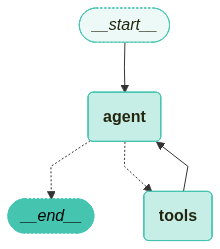

In [12]:
from langchain_teddynote.graphs import visualize_graph

visualize_graph(agent_executor)

## 스트림 출력 함수 정의

React Agent의 실행 과정을 실시간으로 모니터링할 수 있는 스트림 출력 기능을 설정합니다. 이를 통해 에이전트가 각 단계에서 어떤 추론과 행동을 수행하는지 관찰할 수 있습니다.

In [13]:
from langchain_teddynote.messages import stream_graph

In [14]:
# Config 설정
config = {"configurable": {"thread_id": "abc123"}}
inputs = {"messages": [("human", "안녕? 내 이름은 테디야")]}

# 그래프 스트림
stream_graph(agent_executor, inputs, config, node_names=["agent"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
안녕, 테디! 만나서 반가워. 오늘은 어떤 도움이 필요해? 😊

In [15]:
config = {"configurable": {"thread_id": "abc123"}}
inputs = {"messages": [("human", "내 이름이 뭐라고?")]}

# 그래프 스트림
stream_graph(agent_executor, inputs, config, node_names=["agent"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
네 이름은 테디야! 맞지? 😊

In [16]:
config = {"configurable": {"thread_id": "abc123"}}
inputs = {
    "messages": [
        ("human", "AI Brief 보고서에서 Anthropic 투자 관련된 정보를 요약해줘.")
    ]
}
stream_graph(agent_executor, inputs, config, node_names=["agent", "tools"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
<document><context>£ 연구비 지원과 증거 기반 정책 개발, 경제 데이터 측정의 3개 축으로 프로그램 진행
n (연구비 지원) AI가 노동, 생산성, 가치 창출에 미치는 영향을 조사하기 위해 연구자들의 상시 신청을
받아 최대 만 달러의 연구비 보조금과 API 크레딧, 파트너십을 지원
∙ 앤스로픽은 프로그램에 참여하는 학계 및 연구기관 생태계 확장을 위해 독립 연구기관과 제휴할 계획으로,
AI의 경제적 활용 관련 연구 지원을 위해 제휴 연구기관에 API 크레딧과 기타 자원을 제공할 예정
n (증거 기반 정책 개발) 연구자, 정책 입안자, 실무자가 실제 데이터를 활용해 AI의 경제적 영향에
대비하기 위한 정책 제안을 개발하고 평가할 수 있는 공개 포럼을 개최
∙ AI의 영향에 대응하기 위한 증거 기반의 정책 제안을 2025년 7월 25일까지 모집하며, 선정된 제안
작성자는 앤스로픽이 2025년 가을 워싱턴 D.C. 와 유럽에서 개최하는 심포지엄에 발표자로 초대 예정
∙ 앤스로픽은 18개월 내 채택할 수 있는 명확한 구현 방법을 갖추고 실증적 증거를 토대로 생산성과 노동
시장 변화와 관련된 구체적인 정책 권고 사항을 제시할 것을 요구
n (경제 데이터 측정) 앤스로픽 경제 지수를 확장하여 AI의 경제적 활용과 영향을 추적하는 종단 데이터를
생성하고, 정기적으로 데이터와 연구 결과를 공개
출처 | Anthropic, Introducing the Anthropic Economic Futures Program, 2025.06.27.
24</context><metadata><source>data/SPRI_AI_Brief_2025_08.pdf</source><page>25</page></metadata></document

In [17]:
config = {"configurable": {"thread_id": "abc123"}}
inputs = {
    "messages": [
        (
            "human",
            "한강 작가의 노벨상 수상 관련된 뉴스를 검색하고 보고서 형식에 맞게 작성해줘",
        )
    ]
}
stream_graph(agent_executor, inputs, config, node_names=["agent", "tools"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "한강 작가 노벨상 수상", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://namu.wiki/w/%ED%95%9C%EA%B0%95(%EC%86%8C%EC%84%A4%EA%B0%80)/%EB%85%B8%EB%B2%A8%EB%AC%B8%ED%95%99%EC%83%81%20%EC%88%98%EC%83%81", "title": "한강(소설가)/노벨문학상 수상 - 나무위키:대문", "content": "### 2.4. 시상식(/edit/%ED%95%9C%EA%B0%95(%EC%86%8C%EC%84%A4%EA%B0%80)/%EB%85%B8%EB%B2%A8%EB%AC%B8%ED%95%99%EC%83%81%20%EC%88%98%EC%83%81?section=6)\n\n그리하여 한국 시간으로 2024년 12월 11일 자정, 스톡홀름 콘서트홀에서 (노르웨이에서 몇시간 앞서 시상된) 평화상을 제외한 나머지 4개 부문의 수상자들과 함께, 노벨상 시상식에서 공식적으로 노벨문학상을 받았다. 상은 스웨덴 국왕 칼 16세 구스타프가 전달했다. 한강이 받은 금메달은 알프레드 노벨의 얼굴이, 뒷면에는 한강의 이름이 새겨져 있다. 오직 문학상에만 주어지는 양피지 증서를 받았는데, ‘스웨덴 한림원(SVENSKA AKADEMIEN)’과 노벨의 이름 아래 한강의 영문 이름이 특별한 서체의 금색으로 새겨졌다. 간혹 수상자의 특성을 반영한 삽화가 들어가는 것도 있으나, 한강의 증서에는 별도의 삽화가 담기지는 않았다.(#fn-13 \"전년도 문학상을 받은 노르웨이 작가 욘 포세의 증서도 삽화가 없는 양식이었다.\")#  \n  \n본래는 

In [18]:
instruction = """
당신의 임무는 `보도자료`를 작성하는 것입니다.
----
다음의 내용을 순서대로 처리해 주세요.
1. `한강 작가의 노벨상 수상` 관련된 뉴스를 검색해 주세요.
2. 노벨상 수상 관련 뉴스를 바탕으로 보고서 / 보드자료 작성해 주세요.
3. 단, 중간에 요점 정리를 위한 markdown 테이블 형식 요약을 적극 활용해 주세요.
4. 출력 결과를 파일로 저장해 주세요. (파일 이름은 "agent_press_release.md")
"""

In [19]:
config = {"configurable": {"thread_id": "abc123"}}
inputs = {"messages": [("human", instruction)]}
stream_graph(agent_executor, inputs, config, node_names=["agent", "tools"])


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "한강 작가 노벨상 수상", "response_time": 2.63, "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://namu.wiki/w/%ED%95%9C%EA%B0%95(%EC%86%8C%EC%84%A4%EA%B0%80)/%EB%85%B8%EB%B2%A8%EB%AC%B8%ED%95%99%EC%83%81%20%EC%88%98%EC%83%81", "title": "한강(소설가)/노벨문학상 수상 - 나무위키:대문", "content": "### 2.4. 시상식(/edit/%ED%95%9C%EA%B0%95(%EC%86%8C%EC%84%A4%EA%B0%80)/%EB%85%B8%EB%B2%A8%EB%AC%B8%ED%95%99%EC%83%81%20%EC%88%98%EC%83%81?section=6)\n\n그리하여 한국 시간으로 2024년 12월 11일 자정, 스톡홀름 콘서트홀에서 (노르웨이에서 몇시간 앞서 시상된) 평화상을 제외한 나머지 4개 부문의 수상자들과 함께, 노벨상 시상식에서 공식적으로 노벨문학상을 받았다. 상은 스웨덴 국왕 칼 16세 구스타프가 전달했다. 한강이 받은 금메달은 알프레드 노벨의 얼굴이, 뒷면에는 한강의 이름이 새겨져 있다. 오직 문학상에만 주어지는 양피지 증서를 받았는데, ‘스웨덴 한림원(SVENSKA AKADEMIEN)’과 노벨의 이름 아래 한강의 영문 이름이 특별한 서체의 금색으로 새겨졌다. 간혹 수상자의 특성을 반영한 삽화가 들어가는 것도 있으나, 한강의 증서에는 별도의 삽화가 담기지는 않았다.(#fn-13 \"전년도 문학상을 받은 노르웨이 작가 욘 포세의 증서도 삽화가 없는